# Werkspoorbrug (Amsterdam-Rhine Canal)

## Working file



## Importing Required Packages

Below, the required packages are imported. To run this notebook successfully, your environment must include the required dependencies. The virtual environment provided in MUDE, called **`mude-base`**, is sufficient for this purpose.

In addition, several plotting settings are defined, and the local optimisation code is imported. It is important that the provided zip file is extracted in its entirety, as the structure of the directory is required for the imports to work correctly.

The local module `genetic_algorithm_pfm` is imported using a **relative import**, which depends on the directory structure of the project. When the notebook is executed within the provided directory structure, this will work as intended. However, running the notebook outside of this directory will result in the following error: `ModuleNotFoundError: No module named 'genetic_algorithm_pfm'`

In [2]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import pchip_interpolate
from scipy.optimize import minimize 

# Define default plotting parameters
plt.rcParams['font.size'] = '10'  
plt.rcParams['savefig.dpi'] = 300  

# Import local module for genetic algorithm
from genetic_algorithm_pfm import GeneticAlgorithm 

## Design Variables and Bounds

The design constraints for the Werkspoorburg.

| Variable | Description | Unit | Type |
|----------|-------------|------|------|
| `x1` | Clearance height | m | Continuous |
| `x2` | Span | m | Continuous |
| `x3` | Thickness slab | m | Continuous |
| `x4` | Width | m | Continuous | 

**Note:** In the code, design variables are defined only by their type (discrete or continuous) and their bounds — *not* by their physical meaning. Before implementing, it is good practice to write down your choice of design variables on paper, including their units and expected ranges. This helps avoid errors and builds physical intuition for the problem.




`X_irl` contains a reference design based on a real-world installation, which will later be used for comparison against the optimised solutions. Its design variable values are:

In [1]:
# Define the names of variables for later use in plotting and analysis
design_variables = (
    ('x1', 'Clearance height',           'm'),
    ('x2', 'Span', 'm'),
    ('x3', 'Thickness slab',       'm'),
    ('x4', 'Width',     'm')
)

# set bounds for all variables
b1 = [3, 30]      # x1
b2 = [50, 400]       # x2
b3 = [0.2, 5]       # x3
b4 = [3, 40]      # x4
bounds = [b1, b2, b3, b4]

X_irl = [9.1, 200, 3, 5.5] #reference is Bert Swartbrug (Zuidhoorn) singe track archbridge Netherlands
plot_irl = True  # Can be true or False, depending on whether you want to plot the IRL point or not

## Constraints

Constraints ensure that all solutions remain physically feasible. For this artificial reef model, one physical constraint is considered: **the reef has a minimum distance from the beach**. This constraint, `constraint_1`, is a simple geometric relation corresponding to the distance `x5` shown in the figure above. A constraint function may use as many or as few design variables as necessary.

Each *constraint function* must be expressed as an algebraic expression of the form:

$$g(\mathbf{x}) \leq 0 \quad \text{(feasible)}$$

> **Important:** The constraint function should return only the value of $g(\mathbf{x})$ — do *not* encode the inequality inside the function. The inequality type (`'ineq'`) is specified separately when registering the constraint in `cons`, and the optimiser handles the comparison.

The constraints are registered as follows:

```python
cons = [['ineq', constraint_1], ['ineq', constraint_2]]
```

In [3]:
def constraint_1(variables):
    """Minimum distance from end of reef to the shore:

    :return: 1-D array (length n) with constraint values; arr>0 means violation for 'ineq' constraints.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    x3 = variables[:, 2]
    x4 = variables[:, 3]
    min_dis = 30      # minimum distance from end of reef to the shore [m]
    
    return -1 * (x4 - min_dis - x1 * np.cos(np.radians(x3))) # < 0

def constraint_2(variables):
    """Constraint placeholder: return per-individual zeros (no violation).

    :return: 1-D array (length n) with constraint values; arr>0 means violation for 'ineq' constraints.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    x3 = variables[:, 2]
    x4 = variables[:, 3]
    
    return np.zeros_like(x1) # < 0     # Placeholder: no constraint, return zeros meaning no violation


cons = [['ineq', constraint_1], ['ineq', constraint_2]]

## Objective Functions

This model optimises five objectives, each representing a different stakeholder identified during the preceding stakeholder analysis. The table below summarises which objective was chosen to represent each stakeholder.

| Stakeholder | Objective | Unit |
|-------------|-----------|------|
| Government | Construction cost | $ |
| Nature organisations | Carbon emmisions | ton |
| Citizens | Maintenance | days |
| Companies | Capacity | Ships/trains hr |


Each objective is then expressed as a function of the design variables. Where needed, physical constants are introduced to make the units consistent — reasonable estimates are sufficient.

In [4]:
# Define objective functions

def objective_function_1(x1, x2, x3, x4):
    """
    Cost function.
    
    :return: float of construction cost in dollars.
    """
    cons1 = 2.85    # costs per material
    cons2 = 35      # material used per metre length
    cons3 = 10      # material used per metre depth

    return cons1 * cons2 * cons3 * x1 * (10 - x2)


def objective_function_2(x1, x2, x3, x4):
    """
    Ride-length function.
    
    :return: float of ride length in meters.
    """
    cons4 = 0.75    # ride length gained per metre length
    cons5 = 1.5     # ride length dependence on depth variable
    cons6 = 1.8     # optimal reef depth for ride length
    cons7 = 0.005   # sensitivity variable of ride length to peel angle
    cons8 = 60      # optimal peel angle

    return (cons4 * x1) / ((cons5 * (x2 - cons6)**2) + (cons7 * (x3 - cons8)**2) + 1)


def objective_function_3(x1, x2, x3, x4):
    """
    Sediment-trapping function.
    
    :return: float of sediment trapping in cubic meters per year.
    """
    cons9 = 375000  # sediment trapping sensitivity value for length
    cons10 = 1      # y intercept for depth function
    cons11 = 30     # minimum length
    cons12 = 0.25   # sensitivity of depth in overall function

    return ((cons9 * (x1 - cons11)) / 750) * (cons10 - cons12 * x2) * (
        np.exp(-((x4 - x1 * np.sin(np.radians(x3)) - 30) / 50)**2) + 1)


def objective_function_4(x1, x2, x3, x4):
    """
    Safety function.
    
    :return: float of safety in terms of expected number of injuries per year.
    """
    cons13 = 1.2     # sensitivity variable for safety and depth
    cons14 = 0.5     # minimum depth value
    cons15 = 15      # maximum amount of injuries per year
    cons16 = 30      # sensitivity variable for safety and distance from end of reef to the shore
    cons17 = 2       # minimum amount of injuries per year

    return (-cons13 * (x2 - cons14)**2 + (cons15 / 2)) + (((cons15 / 2) - 2) * np.exp(
        -((x4 - x1 * np.sin(np.radians(x3))) / cons16)**2) + cons17)


def objective_function_5(x1, x2, x3, x4):
    """
    Economic growth function.
    
    :return: float of predicted economic growth in dollars.
    """
    cons18 = 60     # Economic return factor on initial cost
    cons19 = 2.85   # costs per material
    cons20 = 35     # material used per metre length
    cons21 = 10     # material used per metre depth

    return cons18 * (cons19 * cons20 * cons21 * x1 * (10 - x2))


# Define the list of objectives with their corresponding names and units and stakeholders for later use in plotting and analysis
objectives = [
    (objective_function_1, "Cost",              "$",            "City Council"),
    (objective_function_2, "Ride Length",       "m",            "Surfing Community"),
    (objective_function_3, "Sediment Trapping", "m^3/year",     "Research Community"),
    (objective_function_4, "Safety",            "accidents/yr", "Local Community"),
    (objective_function_5, "Economic Growth",   "$",            "Tourism")
]


While developing the objectuve functions, it can be helpful to investigate their behavior. Here the attainable minimum and maximum of each objective is computed. These ranges serve as a sanity check — if the values are physically unreasonable, revisit the formulation and its constants. The ranges also define the interval over which each objective is rated in the preference functions.

Optionally, the objective functions can be visualised using `matplotlib` or [Desmos](https://www.desmos.com/calculator) to further inspect their behaviour.

To compute the minimum and maximum values we can use the `minimize` command, which is part of the SciPy package. For more infomration see: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html.

In [5]:
# Finding min and max for each objective using scipy's minimize function, starting from the midpoint of the bounds
objective_minmax = {} # Dictionary to store the min and max values for each objective       
midpoints = [np.mean(b) for b in bounds]

for idx, (obj_func, name, unit, stakeholder) in enumerate(objectives):
    wrapped = lambda x, sign=1: sign * obj_func(*x)  # obj_func accepts a single array-like X
    
    min_val =  minimize(wrapped, x0=midpoints, bounds=bounds, method='L-BFGS-B').fun
    max_val = -minimize(lambda x: wrapped(x, sign=-1), x0=midpoints, bounds=bounds, method='L-BFGS-B').fun

    objective_minmax[name] = min_val, max_val
    print(f"  Objective {idx+1}  :    min = {min_val:>15,.1f}  {unit:<12}    max = {max_val:>15,.1f}  {unit}")


  Objective 1  :    min =       209,475.0  $               max =     4,264,312.5  $
  Objective 2  :    min =             6.4  m               max =           337.5  m
  Objective 3  :    min =             0.0  m^3/year        max =       367,500.0  m^3/year
  Objective 4  :    min =             2.0  accidents/yr    max =             9.5  accidents/yr
  Objective 5  :    min =    12,568,500.0  $               max =   255,858,750.0  $


## Weights

When combining multiple objectives into a single score, each objective is assigned a weight **$w_i$** reflecting its relative importance. All weights must sum to one:

$$\sum_{i=1}^{5} w_i = 1$$

| Weight | Stakeholder | Objective |
|--------|-------------|-----------|
| $w_1$ | City council | Cost |
| $w_2$ | Surfing community | Ride length |
| $w_3$ | Research community | Sediment trapping |
| $w_4$ | Local community | Safety |
| $w_5$ | Tourism | Economic growth |

In this model, all weights are initialised equally ($w_i = \frac{1}{5} = 0.2$) for simplicity.

In [6]:
# Weights per stakeholder — must sum to 1. Before game all weights were set equal.
#                   cost   ride  sed   safe  econ
weights_before =    [0.20, 0.20, 0.20, 0.20, 0.20]
weights_after =     [0.30, 0.15, 0.20, 0.20, 0.15]

weights = weights_before  # set to which weight to use

# Verify the weights sum to 1 (within numerical tolerance)
assert np.isclose(sum(weights), 1.0), f"Weights must sum to 1, got {sum(weights)}"

## Preference Curves and Preference Functions

Each objective value is mapped to a preference score between 0 and 100 using a *preference curve*, which represents a stakeholder's preference towards their objective. This allows objectives with different units and scales to be compared and combined, where 0 indicates the least desirable outcome and 100 the most desirable.

The curves are defined by a set of control points interpolated using `pchip_interpolate` from the SciPy package, which produces smooth curves that pass exactly through each point. Only the shape of the matters — so no analytical function is needed. Creating preference curves using interpolation is a convenient and flexible approach. Start simple and increase complexity only if necessary; aim to capture the essential behaviour with as few points as possible. The prefence curves are then plotted.

For this reef model, four objectives are rated linearly in the technical cycle. The exception is sediment trapping (objective 3), which follows a non-linear preference: too little trapping fails to widen the beach, but too much blocks sediment from reaching downstream beaches — so an intermediate value is preferred.

Each preference curve is then combined with its corresponding objective function to form a *preference function*, which maps design variables directly to a preference score.

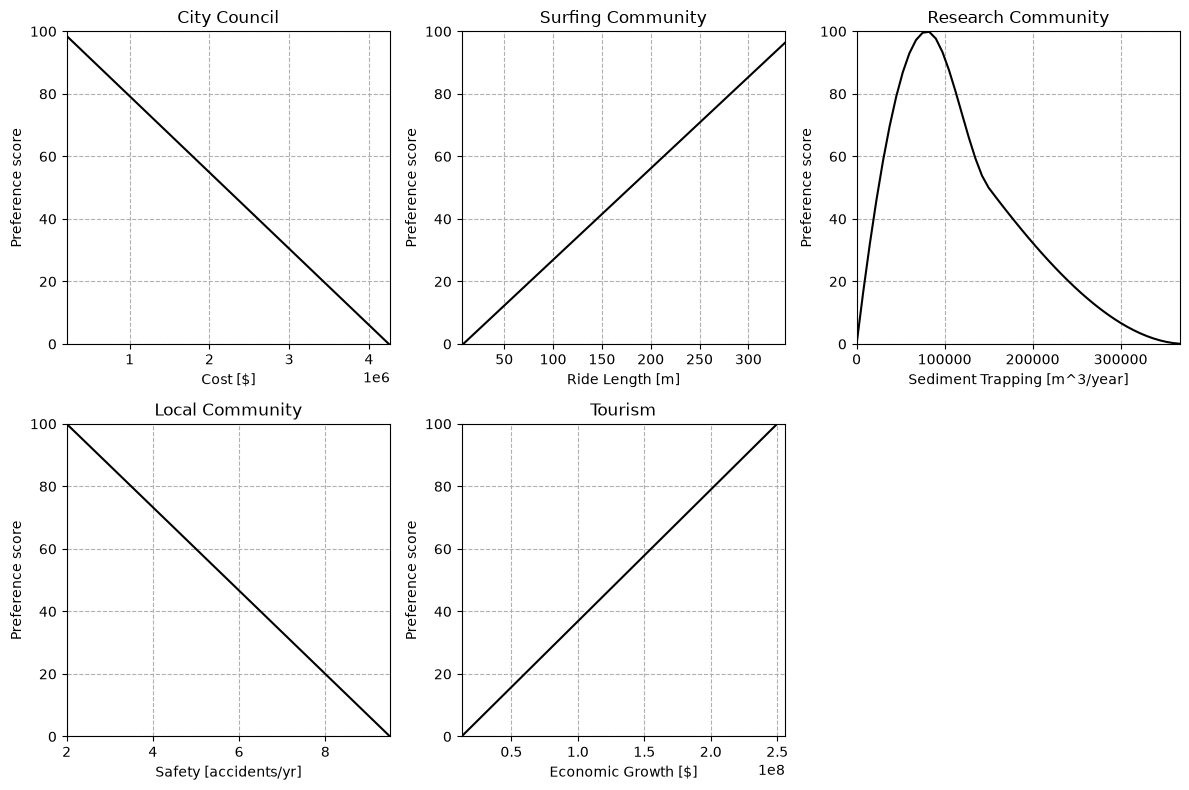

In [7]:
# Define preferences
prefs_before = [[[150000, 4250000],             [100, 0]],          # preference cost
                [[8, 350],                      [0, 100]],          # preference ride length
                [[0, 80000, 150000, 375000],    [0, 100, 50, 0]],   # preference sediment trapping
                [[2, 9.5],                      [100, 0]],          # preference safety
                [[12500000, 250000000],                [0, 100]]]          # preference economic growth

pref_after = [[[150000, 2000000, 4250000],      [100, 80, 0]],
                [[8, 120, 350],                 [0, 60, 100]],
                [[0, 80000, 150000, 375000],    [0, 100, 50, 0]],
                [[2, 9.5],                      [100, 0]],
                [[12500000, 250000000],                [0, 100]]]

prefs = prefs_before  # set to which preferences to use


# Preference curve values for plotting
# Generate objective value ranges 
obj_vals_list = []
for _, name, _, _ in objectives:
    obj_vals = np.linspace(*objective_minmax[name])
    obj_vals_list.append(obj_vals)

# Generate preference values using interpolation
pref_vals_list = []
for pref, obj_vals in zip(prefs, obj_vals_list):
    pref_vals = pchip_interpolate(pref[0], pref[1], obj_vals)
    pref_vals_list.append(pref_vals)

# Plotting the preference curves 
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, (obj_vals, p_vals), (_, name, unit, stakeholder) in zip(axes.flat, zip(obj_vals_list, pref_vals_list), objectives): # Loop to plot each preference curve in its own subplot
    ax.plot(obj_vals, p_vals, color='black')
    ax.set_xlim(min(obj_vals), max(obj_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

axes.flat[-1].set_visible(False)  # hide empty 6th subplot
fig.tight_layout()
# plt.savefig('preference_curves.png')  # Uncomment this line to save the figure as a PNG file
plt.show()


# Defines preference functions that convert raw objective values to 0-100 preference scores
def pref_func_1(x1, x2, x3, x4):
    cost = objective_function_1(x1, x2, x3, x4)
    return pchip_interpolate(prefs[0][0], prefs[0][1], cost)

def pref_func_2(x1, x2, x3, x4):
    ride = objective_function_2(x1, x2, x3, x4)
    return pchip_interpolate(prefs[1][0], prefs[1][1], ride)

def pref_func_3(x1, x2, x3, x4):
    sed = objective_function_3(x1, x2, x3, x4)
    return pchip_interpolate(prefs[2][0], prefs[2][1], sed)

def pref_func_4(x1, x2, x3, x4):
    safe = objective_function_4(x1, x2, x3, x4)
    return pchip_interpolate(prefs[3][0], prefs[3][1], safe)

def pref_func_5(x1, x2, x3, x4):
    econ = objective_function_5(x1, x2, x3, x4)
    return pchip_interpolate(prefs[4][0], prefs[4][1], econ)

pref_funcs = [pref_func_1, pref_func_2, pref_func_3, pref_func_4, pref_func_5]  # list of preference functions for easier handling


def objective(variables):
    """
    Objective function that is fed to the GA. Calles the separate preference functions that are declared above.

    :param variables: array with design variable values per member of the population. Can be split by using array
    slicing
    :return: 1D-array with aggregated preference scores for the members of the population.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    x3 = variables[:, 2]
    x4 = variables[:, 3]

    # calculate the preference scores
    p_1 = pref_func_1(x1, x2, x3, x4)
    p_2 = pref_func_2(x1, x2, x3, x4)
    p_3 = pref_func_3(x1, x2, x3, x4)
    p_4 = pref_func_4(x1, x2, x3, x4)
    p_5 = pref_func_5(x1, x2, x3, x4)
    
    return weights, [p_1, p_2, p_3, p_4, p_5]

## Optimisation

Now that everything is in place, we can run the optimisation. For more details on the available configuration options, see the docstring of `GeneticAlgorithm` (accessible via `help()`). Note that a genetic algorithm relies on randomness, so it is expected that results will differ slightly between separate executions.

The optimisation can be run using three aggregation methods: `'minmax'`, `'a-fine'`, and optionally `'tetra'`. These methods differ in how the individual preference scores are combined into a group preference during the optimisation process; see `aggregations.md` for more information on how each method works and when to use it. These methods determine, mathematically, what is considered the "best" group preference. However, what is considered "best" is not purely a mathematical question, it also involves a qualitative judgement about which outcome is most appropriate for the problem at hand.

After computing the optimal results, the solutions are plotted on top of their corresponding preference curves.


Run GA with minmax
The type of aggregation is set to minmax
Generation   Best score   Mean             Max stall    Diversity    Number of non-feasible results
0            11.709       90000014.9831    0            0.004        90          
1            10.7095      9000014.021      0            0.066        9           
2            10.5347      1000012.3254     0            0.136        1           
3            10.487       1000011.5009     0            0.192        1           
4            10.487       5000011.2056     1            0.229        5           
5            10.487       5000011.0189     2            0.232        5           
6            10.487       5000010.9624     3            0.237        5           
7            10.487       5000011.0329     4            0.234        5           
8            10.487       4000011.0111     5            0.232        4           
9            10.487       5000010.9606     6            0.232        5           
10           10.487

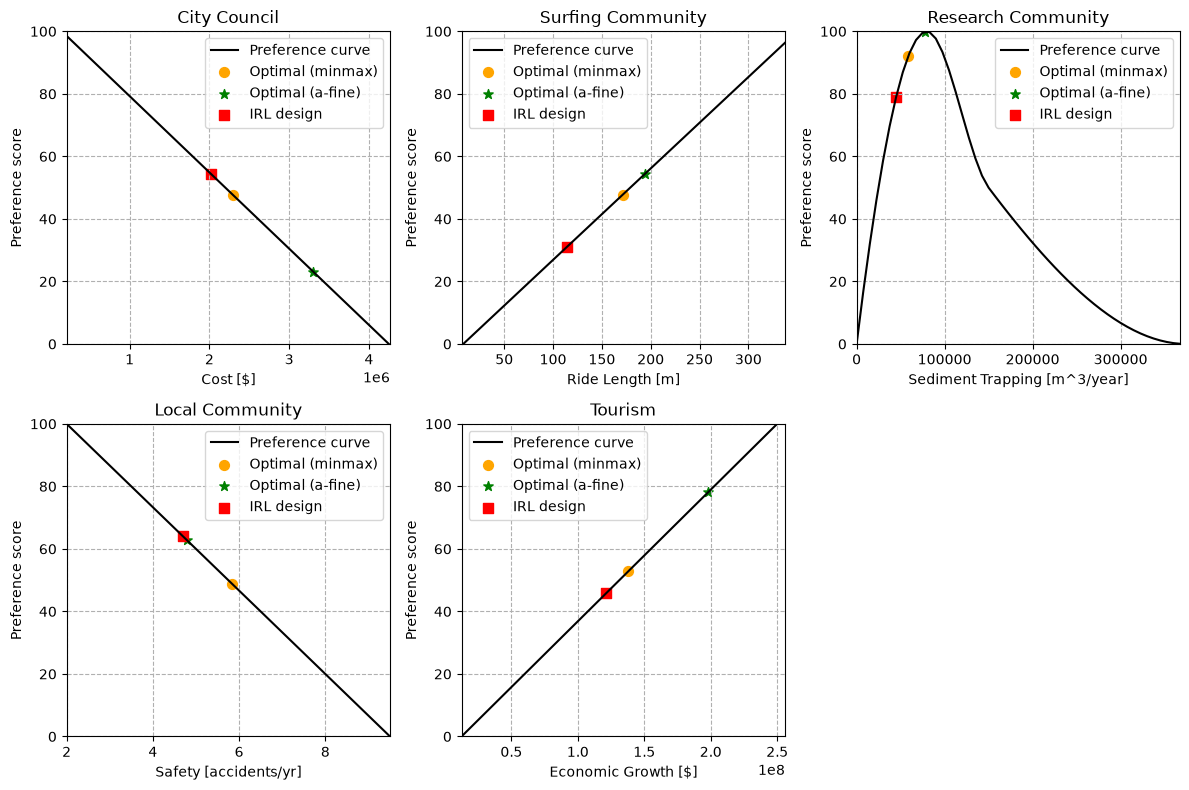

In [ ]:
# We run the optimization with two paradigms
paradigm = ['minmax', 'a-fine', 'tetra']  # 'minmax' or 'a-fine' or 'tetra'
markers  = ['o', '*']
colours  = ['orange', 'green']

# Define the figure and axes before the loop
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Plot underlying preference curves using a loop
for ax, o_vals, p_vals, (_, name, unit, stakeholder) in zip(axes.flat, obj_vals_list, pref_vals_list, objectives): 
    ax.plot(o_vals, p_vals, color='black', label='Preference curve')
    ax.set_xlim(min(o_vals), max(o_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

for i in range(len(paradigm)):
    # Dictionary with parameter settings for the GA run with the IMAP solver
    options = {
        'n_bits': 8,
        'n_iter': 400,
        'n_pop': 500,
        'r_cross': 0.8,
        'max_stall': 16,
        'aggregation': paradigm[i],  
        'var_type': 'real'
    }

    # Run the GA and print its result
    print(f'\nRun GA with {paradigm[i]}')
    ga = GeneticAlgorithm(objective=objective, constraints=cons, bounds=bounds, options=options)
    _, optimal_design_var, _ = ga.run()

    # print the optimal design variable values
    print(f'Optimal design variable values using {paradigm[i]}:') 
    for opt_var, (xi, name, unit) in zip(optimal_design_var, design_variables):
        print(f'  {xi} : {name:<25} = {opt_var:>10.2f} {unit}') 

    # Print and plot the optimal objective results and stakeholder preferences
    print(f'Optimal objective results and stakeholder preference using {paradigm[i]}:')
    for j, (ax, (obj_func, name, unit, stakeholder)) in enumerate(zip(axes.flat, objectives)):
        obj_value = obj_func(*optimal_design_var) # Calculate resulting objective value
        pref_score = pref_funcs[j](*optimal_design_var) # Calculate resulting preference score
    
        # Print and plot the optimal point on the preference curve
        print(f'  {name:<20} = {obj_value:>15,.2f} {unit:<10} -> {stakeholder:<20} pref: {pref_score:>6.2f}')
        ax.scatter(obj_value, pref_score, color=colours[i], marker=markers[i], s=50,
                   label=f'Optimal ({paradigm[i]})')


# plot the IRL design point if plot_irl is True
if plot_irl:   
    irl_obj_values = [obj_func(*X_irl) for obj_func, _, _, _ in objectives]
    irl_pref_scores = [pref_funcs[j](*X_irl) for j in range(len(objectives))]
    for j, ax in enumerate(axes.flat[:5]):
        ax.scatter(irl_obj_values[j], irl_pref_scores[j], color='red', marker='s', s=50, label='IRL design')

for ax in axes.flat[:5]:
    ax.legend(fontsize=10)

axes.flat[-1].set_visible(False)  # hide the sixth empty subplot


# Adjust the layout 
fig.tight_layout()

# Save figure
# plt.savefig('optimal_results.png')  # Uncomment this line to save the figure as a PNG file

# Display the plot
plt.show()